# Final empirical results

This reader-facing notebook displays the final estimation and robustness results from saved analysis artifacts. It does not re-estimate the computationally intensive models. Run it only from the repository-local `.venv`.

> **Claim boundary:** the estimates are conditional associations, not causal effects. Realised renewable output, demand, bidding, outages and network constraints are jointly determined.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

root = Path.cwd().resolve()
if root.name == 'notebooks':
    root = root.parent
assert (root / '.venv').exists(), 'Run from the project repository using its .venv.'
print(f'Project root: {root}')
print(f'Python executable: {sys.executable}')

Project root: /Users/ye/Documents/ChatGPT/gjx/AU_NEM_Renewables_Prices
Python executable: /Users/ye/Documents/ChatGPT/gjx/AU_NEM_Renewables_Prices/.venv/bin/python


## Analysis snapshot

The final model frame is the reproducible, transformation-only input to the frozen specifications.

In [2]:
model = pd.read_parquet(root / 'data/processed/nem_region_hour_model.parquet')
snapshot = pd.DataFrame({
    'metric': ['Observations in model frame', 'Headline four-region observations', 'Dynamic observations', 'AEST ISO-week clusters', 'Study coverage'],
    'value': [len(model), int(model['headline_sample'].sum()), int(model['dynamic_sample'].sum()), model.loc[model['headline_sample'], 'aest_week'].nunique(), f"{model['timestamp'].min():%Y-%m-%d} to {model['timestamp'].max():%Y-%m-%d}"],
})
display(snapshot)

,metric,value
0,Observations in model frame,263040
1,Headline four-region observations,210399
2,Dynamic observations,209928
3,AEST ISO-week clusters,314
4,Study coverage,2019-07-01 to 2025-06-30


## Headline fixed-effects estimates

Effects are per 10 percentage-point increase in the pooled-p99.9-capped wind-plus-utility-solar share, with region-month and exact AEST timestamp fixed effects and AEST-week clustered standard errors.

In [3]:
headline = pd.read_csv(root / 'outputs/tables/task8_headline_results.csv')
headline_view = headline.loc[headline['section'].eq('headline_fixed_effects'), ['outcome_or_contrast', 'estimate', 'std_error', 'p_value', 'nobs', 'week_clusters']].copy()
headline_view = headline_view.rename(columns={'outcome_or_contrast': 'Outcome', 'estimate': 'Estimate', 'std_error': 'Clustered SE', 'p_value': 'p-value', 'nobs': 'N', 'week_clusters': 'Week clusters'})
headline_view[['Estimate', 'Clustered SE', 'p-value']] = headline_view[['Estimate', 'Clustered SE', 'p-value']].round(4)
display(headline_view)

,Outcome,Estimate,Clustered SE,p-value,N,Week clusters
0,Continuous price (asinh RRP),-0.2701,0.0125,0.0,210399,314
1,Continuous price (AUD/MWh level),-11.8020,0.8679,0.0,210399,314
2,Continuous price (winsorised AUD/MWh),-10.4458,0.6369,0.0,210399,314
3,"Any negative price (LPM, probability points)",0.0358,0.0014,0.0,210399,314
4,Negative five-minute-price share (points),0.0202,0.0012,0.0,210399,314
5,Intrahour volatility (asinh SD),-0.0239,0.0042,0.0,210399,314
6,Intrahour volatility (AUD/MWh SD level),-5.0252,0.6837,0.0,210399,314


## Regional heterogeneity

The pooled result is not a universal state-level effect. These four region-specific transformed-price slopes use the same conditional-association boundary.

In [4]:
regional = pd.read_csv(root / 'outputs/tables/task9_heterogeneity_holm.csv')
regional_view = regional.loc[(regional['family'].eq('heterogeneity_region')) & (regional['outcome'].eq('price_asinh')), ['contrast', 'estimate', 'std_error', 'ci_lower', 'ci_upper', 'p_value_holm']].copy()
regional_view = regional_view.rename(columns={'contrast': 'Region', 'estimate': 'Estimate', 'std_error': 'Clustered SE', 'ci_lower': '95% CI lower', 'ci_upper': '95% CI upper', 'p_value_holm': 'Holm-adjusted p-value'})
display(regional_view.round(4))

,Region,Estimate,Clustered SE,95% CI lower,95% CI upper,Holm-adjusted p-value
0,NSW1,0.3765,0.0320,0.3134,0.4395,0.0
1,VIC1,-0.4813,0.0192,-0.5191,-0.4434,0.0
2,QLD1,-0.1898,0.0461,-0.2805,-0.0991,0.0
3,SA1,-0.2830,0.0119,-0.3063,-0.2597,0.0


## Robustness and dynamic inference

The raw, uncapped demand ratio is shown explicitly because it fails the leverage audit: a few near-zero-demand SA1 hours dominate it. It is not an alternative headline estimate.

In [5]:
robustness = pd.read_csv(root / 'outputs/tables/task9_main_robustness_summary.csv')
robustness_view = robustness.loc[robustness['outcome'].eq('price_asinh'), ['family', 'coefficient', 'std_error', 'ci_lower', 'ci_upper', 'nobs', 'covariance']].copy()
robustness_view = robustness_view.rename(columns={'family': 'Specification', 'coefficient': 'Estimate', 'std_error': 'SE', 'ci_lower': '95% CI lower', 'ci_upper': '95% CI upper', 'nobs': 'N', 'covariance': 'Covariance'})
display(robustness_view.round(4))

bootstrap = pd.read_csv(root / 'outputs/tables/task9_week_multiplier_bootstrap.csv')
display(Markdown('**Week score-multiplier inference**'))
display(bootstrap.round(4))

,Specification,Estimate,SE,95% CI lower,95% CI upper,N,Covariance
0,exposure_headline_p999,-0.2701,0.0125,-0.2946,-0.2456,210399,clustered_aest_week_debiased
1,exposure_raw_uncapped,-0.0146,0.0108,-0.0358,0.0066,210399,clustered_aest_week_debiased
2,exposure_cap_at_one,-0.3222,0.0138,-0.3493,-0.2952,210399,clustered_aest_week_debiased
3,exposure_broad_including_hydro,-0.0142,0.0105,-0.0348,0.0063,210399,clustered_aest_week_debiased
4,exposure_wind_solar_output_100mw,-0.0362,0.0044,-0.0447,-0.0277,210399,clustered_aest_week_debiased
5,exposure_separate_wind_solar,-0.0391,0.0131,-0.0647,-0.0135,210399,clustered_aest_week_debiased
6,exposure_separate_wind_solar,0.3060,0.0314,0.2444,0.3675,210399,clustered_aest_week_debiased
7,exposure_all_unknown_as_renewable_upper_bound,-0.2668,0.0126,-0.2914,-0.2422,210399,clustered_aest_week_debiased
8,sample_include_tas1,-0.2766,0.0106,-0.2974,-0.2558,263007,clustered_aest_week_debiased
9,sample_post_5ms,-0.2735,0.0167,-0.3063,-0.2408,131391,clustered_aest_week_debiased


**Week score-multiplier inference**

,model,contrast,estimate,bootstrap_std_error,bootstrap_p_value,ci_lower,ci_upper,nobs,week_clusters
0,distributed_lag_price_asinh,contemporaneous_plus_lags_1_24,-0.3498,0.0144,0.0025,-0.3780,-0.3206,209928,314
1,logit,negative_price_average_marginal_effect,0.0402,0.0009,0.0025,0.0385,0.0419,210399,314
2,probit,negative_price_average_marginal_effect,0.0391,0.0010,0.0025,0.0372,0.0411,210399,314


## Publication figures

### Figure 1 — regional price and renewable-share trends

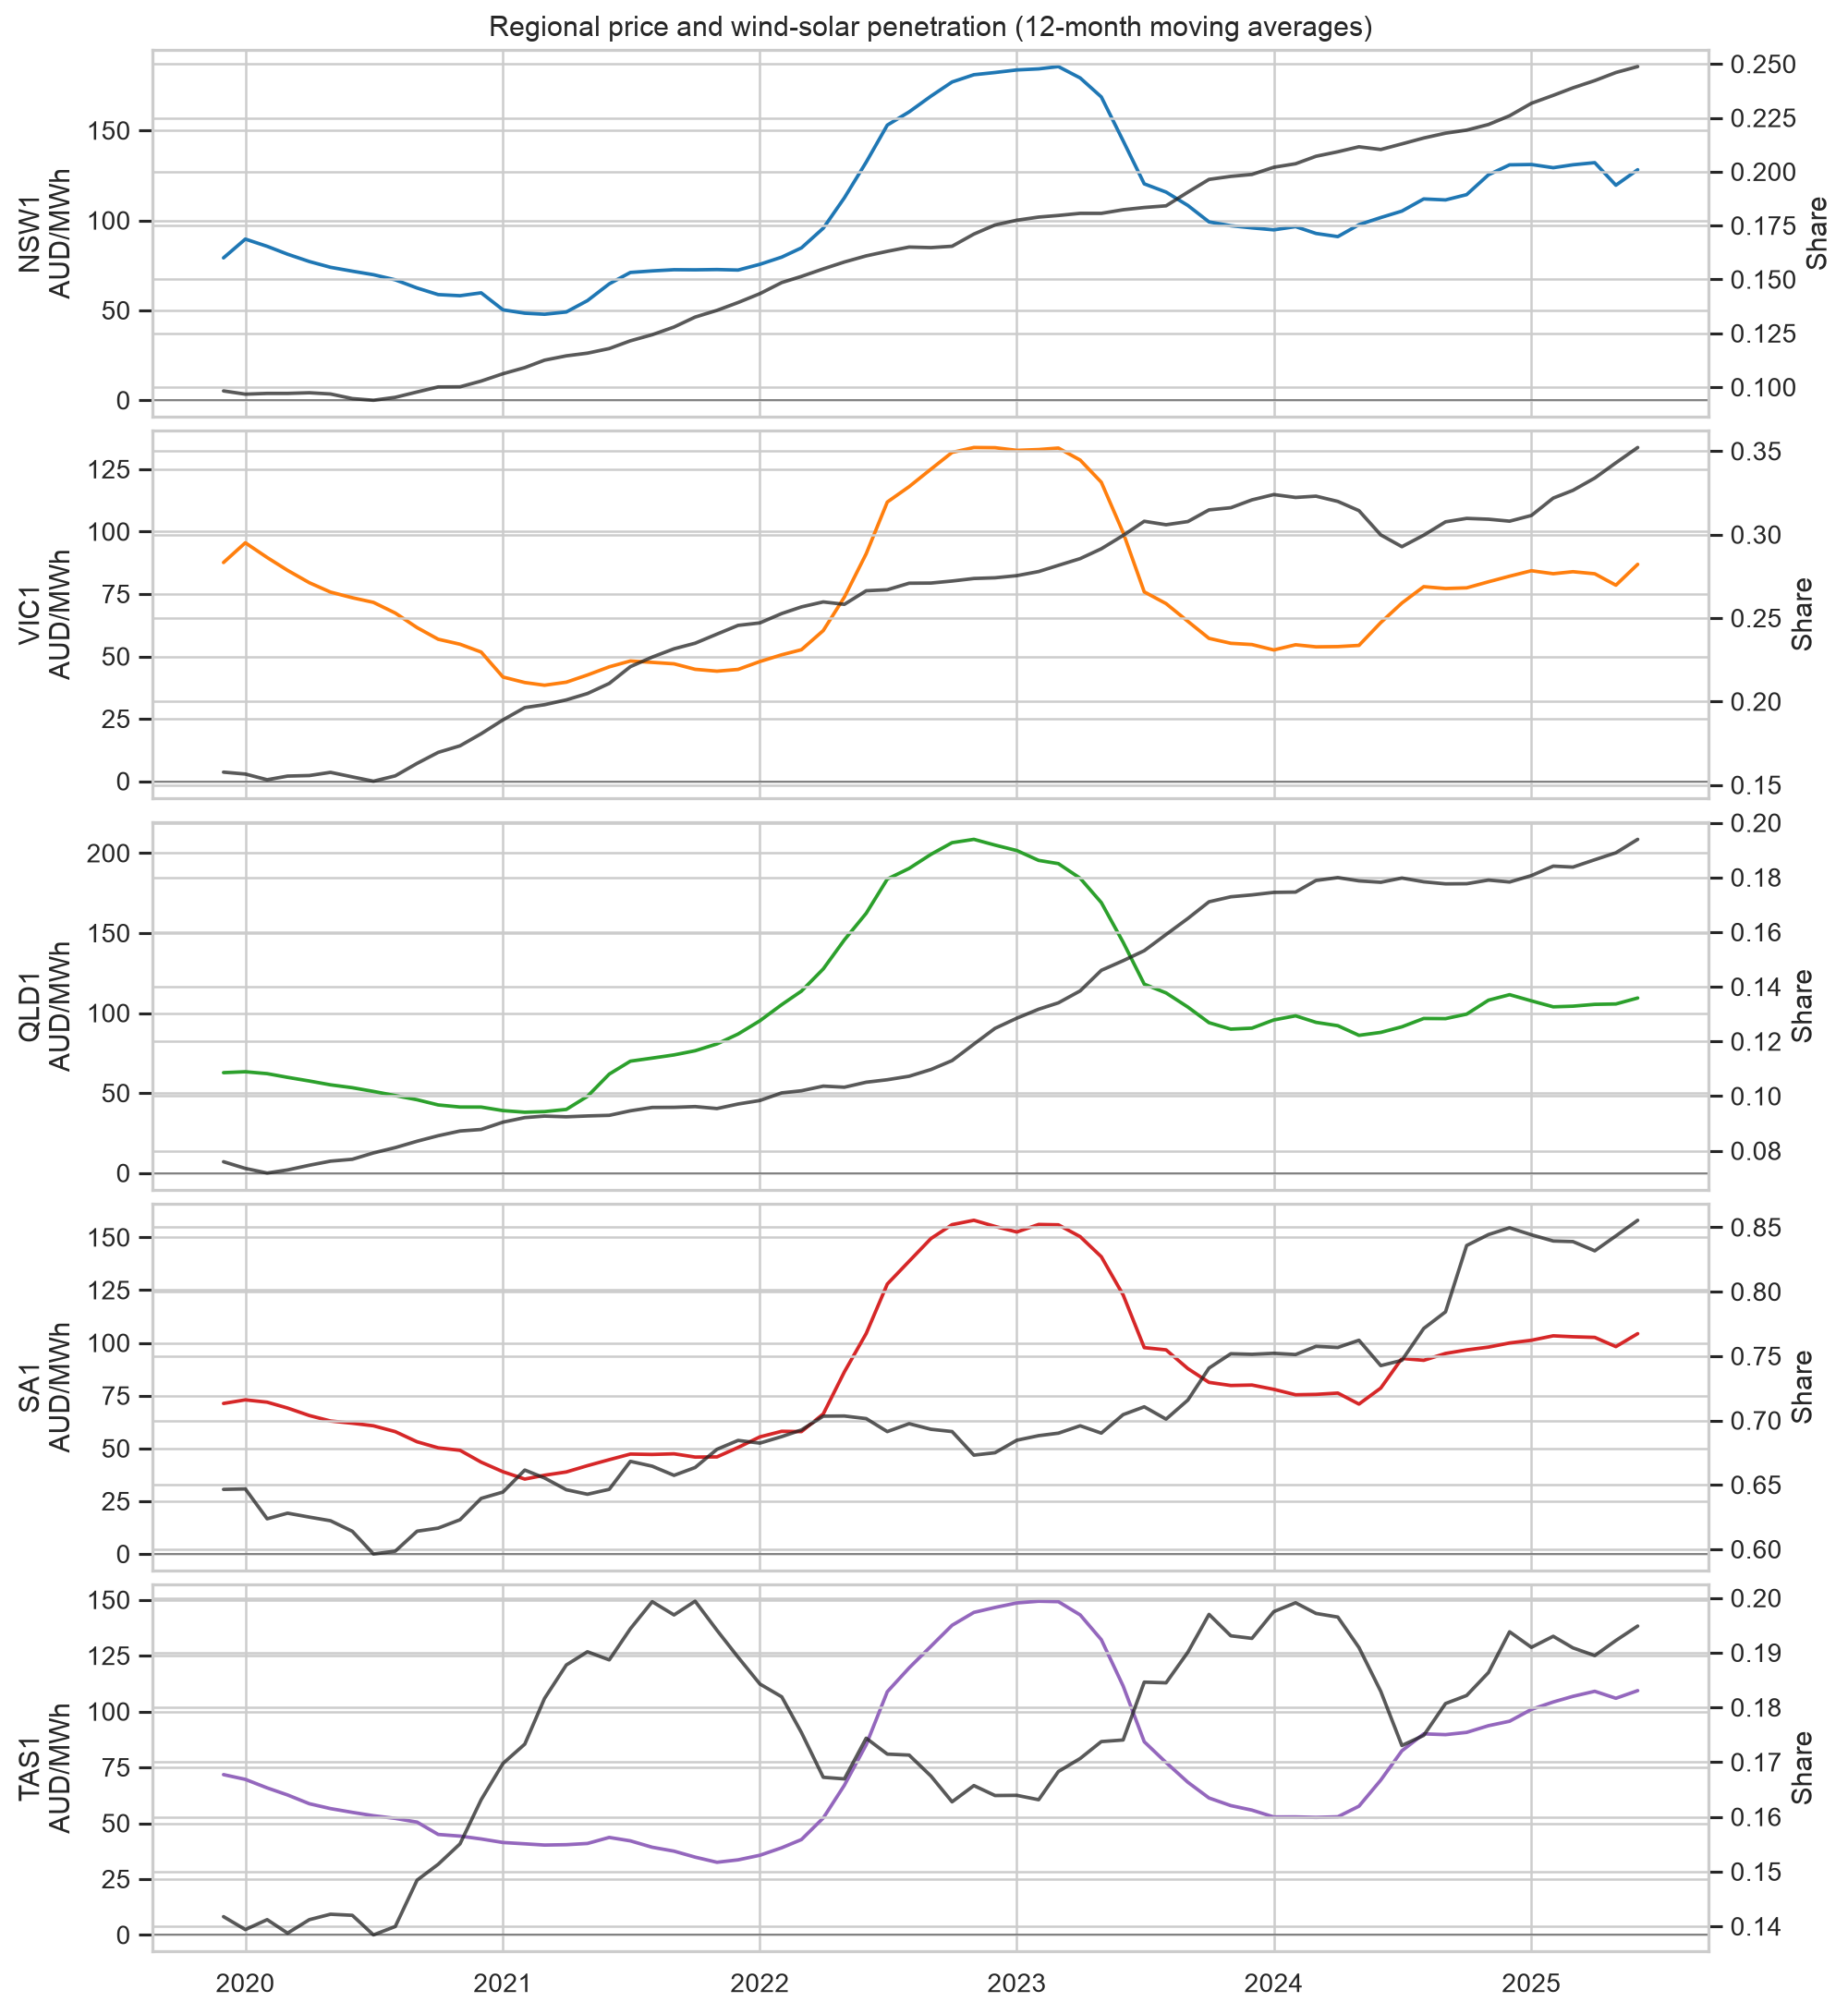

### Figure 2 — regional transformed-price heterogeneity

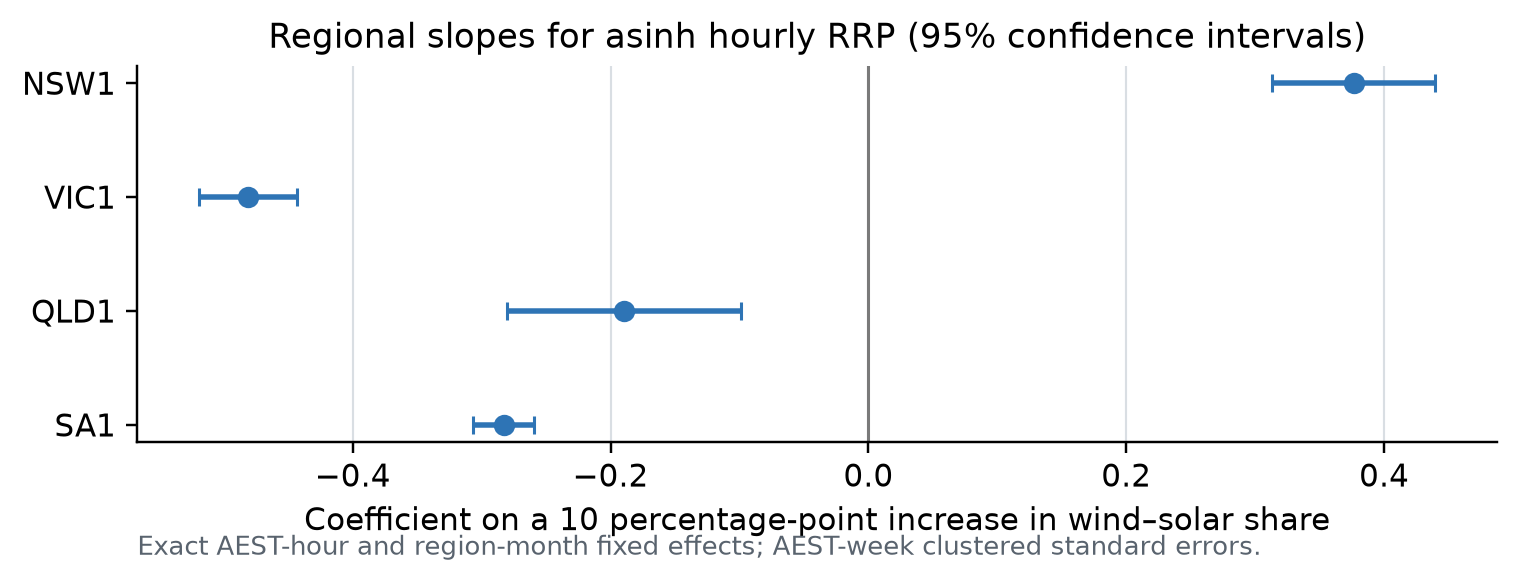

### Figure 3 — price robustness

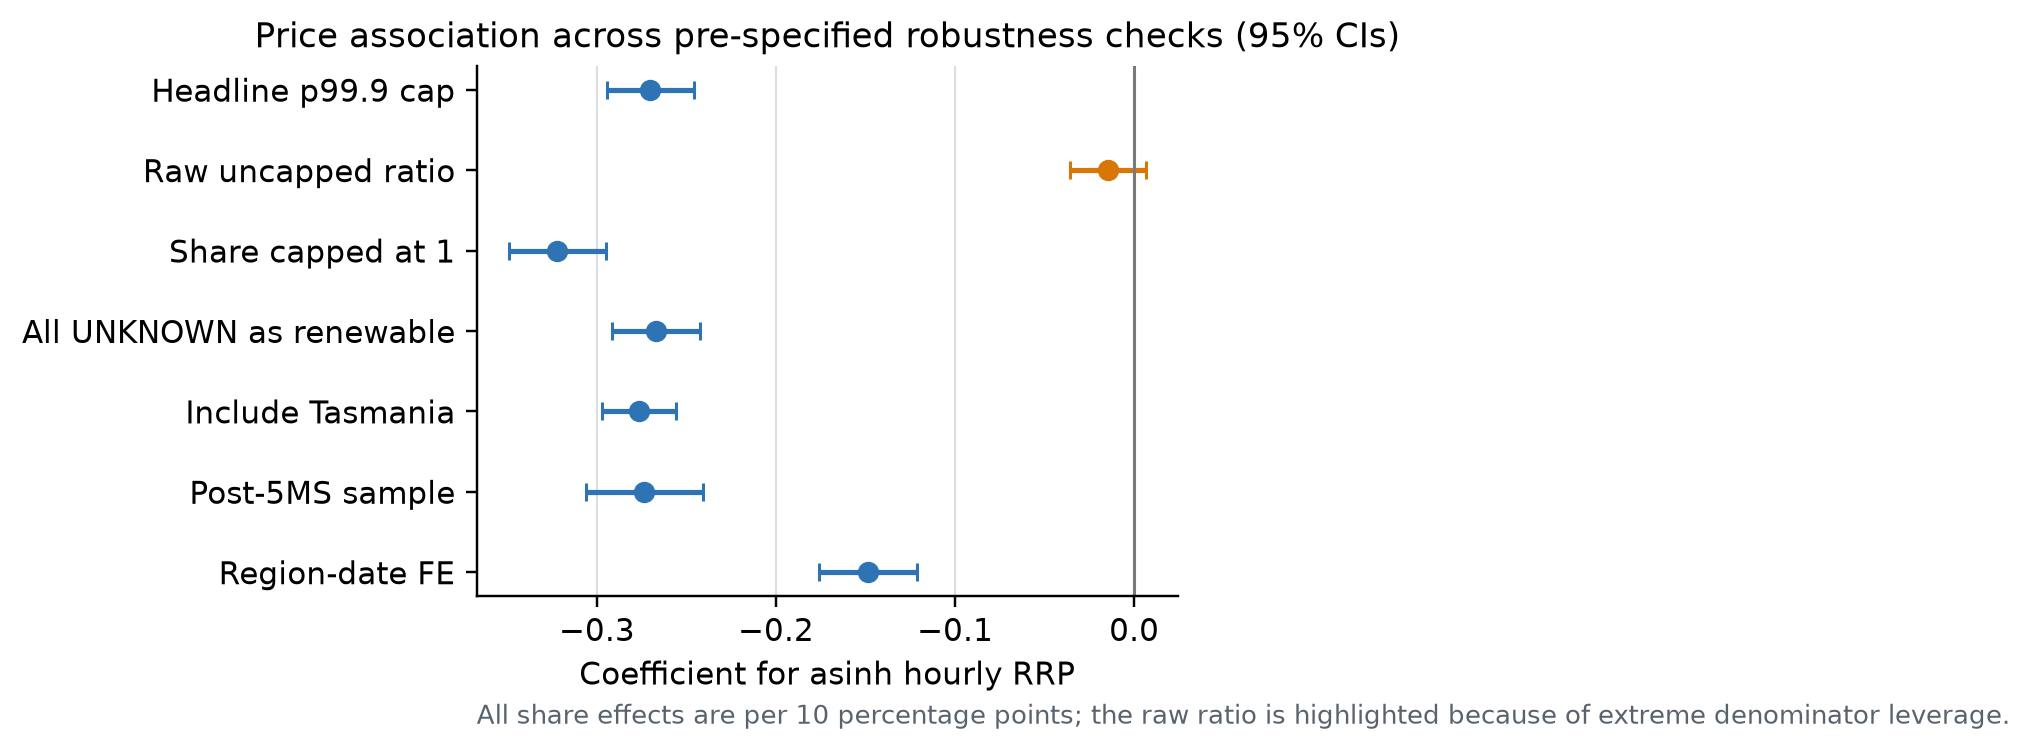

In [6]:
figures = [
    ('Figure 1 — regional price and renewable-share trends', 'fig1_price_and_renewable_share_trends.png'),
    ('Figure 2 — regional transformed-price heterogeneity', 'fig5_regional_price_heterogeneity.png'),
    ('Figure 3 — price robustness', 'fig6_price_robustness.png'),
]
for caption, filename in figures:
    path = root / 'outputs/figures' / filename
    assert path.exists(), f'Missing figure: {path}'
    display(Markdown(f'### {caption}'))
    display(Image(filename=str(path), width=900))

## Reproducibility checks and interpretation

The saved outputs must agree with the frozen analysis snapshot. Full-sample unpenalised quantile models are intentionally absent: they did not complete under bounded computation and have not been replaced by another estimator.

In [7]:
checks = {
    'headline observations': int(model['headline_sample'].sum()) == 210_399,
    'dynamic observations': int(model['dynamic_sample'].sum()) == 209_928,
    'week clusters': model.loc[model['headline_sample'], 'aest_week'].nunique() == 314,
    'headline transformed-price estimate': abs(float(headline.loc[headline['outcome_or_contrast'].eq('Continuous price (asinh RRP)'), 'estimate'].iloc[0]) + 0.270124) < 1e-6,
}
for label, passed in checks.items():
    assert passed, f'FAILED: {label}'
    print(f'PASS — {label}')

print('\nInterpretation: higher wind-plus-utility-solar share is conditionally associated with lower hourly RRP and lower intrahour dispersion, but a higher probability of a negative five-minute price. Do not interpret this as causal.')

PASS — headline observations
PASS — dynamic observations
PASS — week clusters
PASS — headline transformed-price estimate

Interpretation: higher wind-plus-utility-solar share is conditionally associated with lower hourly RRP and lower intrahour dispersion, but a higher probability of a negative five-minute price. Do not interpret this as causal.
